In [1]:
print("AKHIL C")
print("24BAD007")

AKHIL C
24BAD007


# Scenario 2 – Customer Segmentation using Gaussian Mixture Models (GMM)


## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Preprocessing and Scaling

In [2]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix: {X_scaled.shape}")

Feature matrix: (200, 2)


## 3 & 4. Apply GMM and Choose Number of Components

In [3]:
aic_scores = []
bic_scores = []
log_likelihoods = []
K_range = range(2, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_scaled)
    aic_scores.append(gmm.aic(X_scaled))
    bic_scores.append(gmm.bic(X_scaled))
    log_likelihoods.append(gmm.score(X_scaled))

best_k_bic = list(K_range)[np.argmin(bic_scores)]
print(f"Optimal K by BIC: {best_k_bic}")

print("\nK | AIC       | BIC       | Log-Likelihood")
for k, a, b, l in zip(K_range, aic_scores, bic_scores, log_likelihoods):
    print(f"{k} | {a:.2f} | {b:.2f} | {l:.4f}")

Optimal K by BIC: 5

K | AIC       | BIC       | Log-Likelihood
2 | 1112.19 | 1148.47 | -2.7255
3 | 1095.65 | 1151.72 | -2.6541
4 | 1003.63 | 1079.49 | -2.3941
5 | 963.00 | 1058.65 | -2.2625
6 | 956.13 | 1071.57 | -2.2153
7 | 950.36 | 1085.59 | -2.1709
8 | 927.46 | 1082.48 | -2.0836
9 | 932.00 | 1106.81 | -2.0650
10 | 919.15 | 1113.75 | -2.0029


## 5. Fit Model using Expectation-Maximization

In [4]:
n_components = 5
gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=5, covariance_type='full')
gmm.fit(X_scaled)
print(f"Converged: {gmm.converged_}")
print(f"Iterations: {gmm.n_iter_}")

Converged: True
Iterations: 5


## 6. Predict Cluster Probabilities

In [5]:
probs = gmm.predict_proba(X_scaled)
prob_df = pd.DataFrame(probs, columns=[f'P(Cluster {i})' for i in range(n_components)])
print("Sample cluster probabilities (first 5 rows):")
print(prob_df.head().round(3))

Sample cluster probabilities (first 5 rows):
   P(Cluster 0)  P(Cluster 1)  P(Cluster 2)  P(Cluster 3)  P(Cluster 4)
0           0.0           0.0         0.001           0.0         0.999
1           0.0           0.0         1.000           0.0         0.000
2           0.0           0.0         0.000           0.0         1.000
3           0.0           0.0         1.000           0.0         0.000
4           0.0           0.0         0.002           0.0         0.998


## 7. Assign Clusters Based on Highest Probability

In [6]:
df['GMM_Cluster'] = gmm.predict(X_scaled)
df['Max_Probability'] = probs.max(axis=1)
print(df['GMM_Cluster'].value_counts().sort_index())
print(f"\nAverage max cluster probability: {df['Max_Probability'].mean():.4f}")

GMM_Cluster
0    84
1    39
2    21
3    33
4    23
Name: count, dtype: int64

Average max cluster probability: 0.9827


## 8. Compare with K-Means

In [7]:
kmeans = KMeans(n_clusters=n_components, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

gmm_sil = silhouette_score(X_scaled, df['GMM_Cluster'])
km_sil = silhouette_score(X_scaled, df['KMeans_Cluster'])

print(f"GMM    Silhouette Score: {gmm_sil:.4f}")
print(f"K-Means Silhouette Score: {km_sil:.4f}")
print(f"GMM    Log-Likelihood:   {gmm.score(X_scaled):.4f}")
print(f"GMM    AIC: {gmm.aic(X_scaled):.2f}")
print(f"GMM    BIC: {gmm.bic(X_scaled):.2f}")

GMM    Silhouette Score: 0.5537
K-Means Silhouette Score: 0.5547
GMM    Log-Likelihood:   -2.2625
GMM    AIC: 963.00
GMM    BIC: 1058.65


## Visualizations

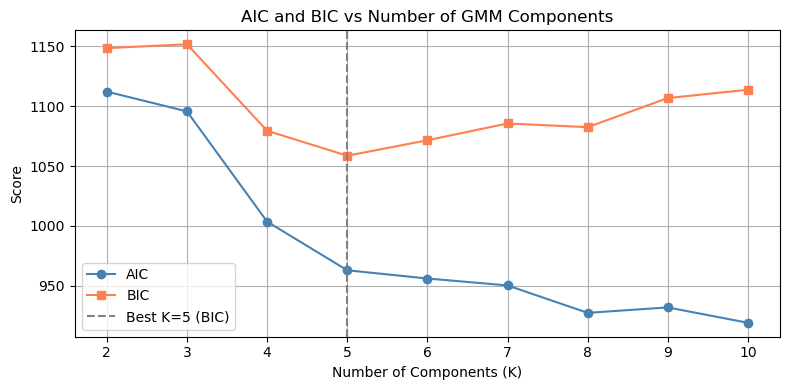

In [8]:
# AIC and BIC vs number of components
plt.figure(figsize=(8, 4))
plt.plot(list(K_range), aic_scores, marker='o', label='AIC', color='steelblue')
plt.plot(list(K_range), bic_scores, marker='s', label='BIC', color='coral')
plt.axvline(best_k_bic, linestyle='--', color='gray', label=f'Best K={best_k_bic} (BIC)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Score')
plt.title('AIC and BIC vs Number of GMM Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

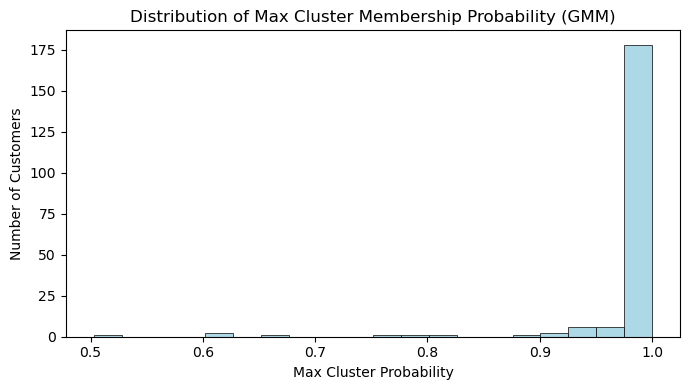

In [14]:
# Cluster probability distribution (max probability per point)
plt.figure(figsize=(7, 4))
plt.hist(df['Max_Probability'], bins=20, color='lightblue', edgecolor='k', linewidth=0.5)
plt.xlabel('Max Cluster Probability')
plt.ylabel('Number of Customers')
plt.title('Distribution of Max Cluster Membership Probability (GMM)')
plt.tight_layout()
plt.show()

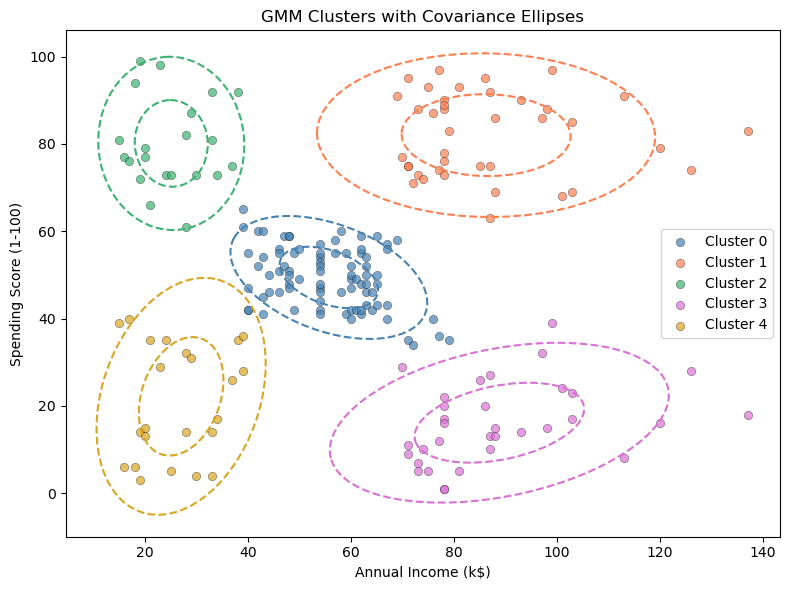

In [12]:
# GMM contour plot with ellipses
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']

def draw_ellipse(mean, cov, ax, color):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    for n_std in [1, 2]:
        width, height = 2 * n_std * np.sqrt(vals)
        ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=color, fc='None', lw=1.5, linestyle='--')
        ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(n_components):
    mask = df['GMM_Cluster'] == c
    ax.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        color=colors[c], label=f'Cluster {c}', alpha=0.7, edgecolors='k', linewidths=0.3
    )
    mean_orig = scaler.inverse_transform(gmm.means_[c].reshape(1, -1))[0]
    cov_orig = gmm.covariances_[c]
    scale = np.diag(scaler.scale_)
    cov_inv = scale @ cov_orig @ scale
    draw_ellipse(mean_orig, cov_inv, ax, colors[c])

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title('GMM Clusters with Covariance Ellipses')
ax.legend()
plt.tight_layout()
plt.show()

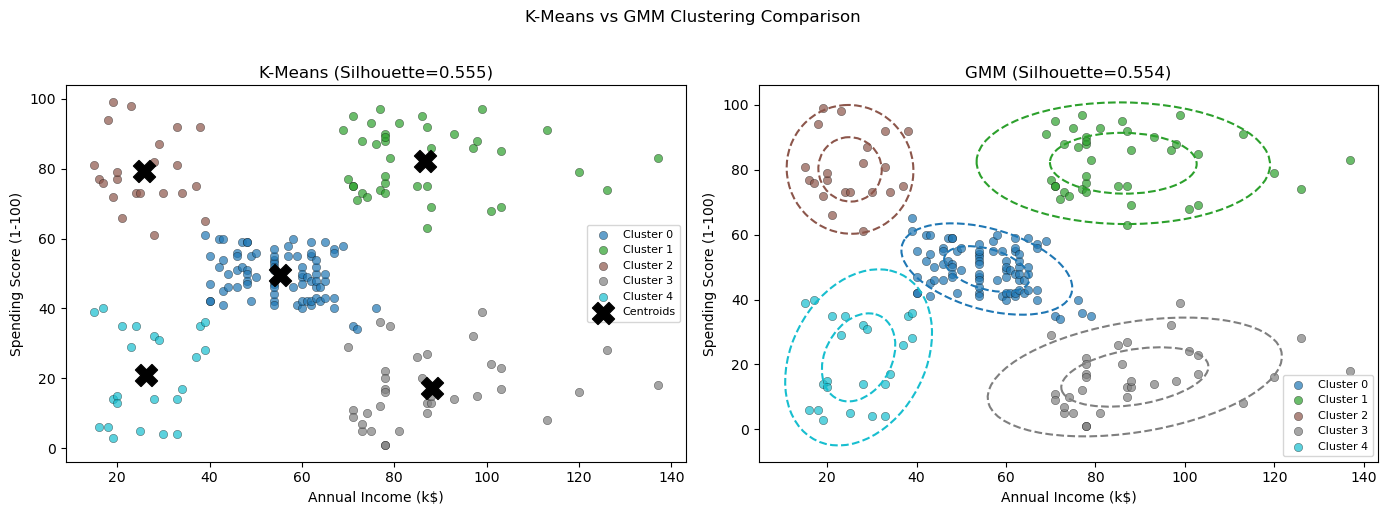

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Dynamic color map (handles any number of clusters)
colors = plt.cm.get_cmap('tab10', n_components)

# Function to draw GMM ellipses
def draw_ellipse(mean, cov, ax, color):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    for n_std in [1, 2]:  
        width, height = 2 * n_std * np.sqrt(vals)
        ell = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            edgecolor=color,
            fc='None',
            lw=1.5,
            linestyle='--'
        )
        ax.add_patch(ell)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert KMeans centroids back to original scale
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

for c in range(n_components):
    mask_km = df['KMeans_Cluster'] == c

    axes[0].scatter(
        df.loc[mask_km, 'Annual Income (k$)'],
        df.loc[mask_km, 'Spending Score (1-100)'],
        color=colors(c),   # ✅ FIXED
        alpha=0.7,
        edgecolors='k',
        linewidths=0.3,
        label=f'Cluster {c}'
    )

# Plot centroids
axes[0].scatter(
    centroids_orig[:, 0],
    centroids_orig[:, 1],
    s=250,
    c='black',
    marker='X',
    zorder=5,
    label='Centroids'
)

axes[0].set_title(f'K-Means (Silhouette={km_sil:.3f})')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend(fontsize=8)

for c in range(n_components):
    mask_gmm = df['GMM_Cluster'] == c

    # Scatter points
    axes[1].scatter(
        df.loc[mask_gmm, 'Annual Income (k$)'],
        df.loc[mask_gmm, 'Spending Score (1-100)'],
        color=colors(c),   # ✅ FIXED
        alpha=0.7,
        edgecolors='k',
        linewidths=0.3,
        label=f'Cluster {c}'
    )

    # Convert mean back to original scale
    mean_orig = scaler.inverse_transform(
        gmm.means_[c].reshape(1, -1)
    )[0]

    # Convert covariance to original scale
    cov_orig = gmm.covariances_[c]
    scale = np.diag(scaler.scale_)
    cov_transformed = scale @ cov_orig @ scale

    # Draw Gaussian ellipse
    draw_ellipse(mean_orig, cov_transformed, axes[1], colors(c))

axes[1].set_title(f'GMM (Silhouette={gmm_sil:.3f})')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(fontsize=8)

# Final layout
plt.suptitle('K-Means vs GMM Clustering Comparison ', y=1.02)
plt.tight_layout()
plt.show()